In [3]:
#Mental Health NLP

In [4]:
#Some EDA

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
posts = pd.read_csv('Combined Data.csv', index_col=0)

In [8]:
posts.sample(10)

,statement,status
40134,i m sick of living the world is going to shit ...,Depression
18362,"Well, I do not usually these kind of of things...",Suicidal
33463,we won't have any money for other things?,Normal
44626,masterballerina haha but then u d have go to c...,Normal
26510,Today was a really rough day. I am currently i...,Suicidal
25218,"Hello guys.I am 18,my parents split up when i ...",Suicidal
47354,venting I need to submit a 4-page paper in the...,Depression
44181,glinner don t think that s the right username ...,Normal
20076,They say awful things to me. I wish they would...,Depression
38377,i am and have been battling depression since t...,Depression


In [9]:
posts.isna().sum()

statement    362
status         0
dtype: int64

In [10]:
posts.dropna(inplace = True)
posts.isna().sum()

statement    0
status       0
dtype: int64

In [11]:
posts.status.value_counts()

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

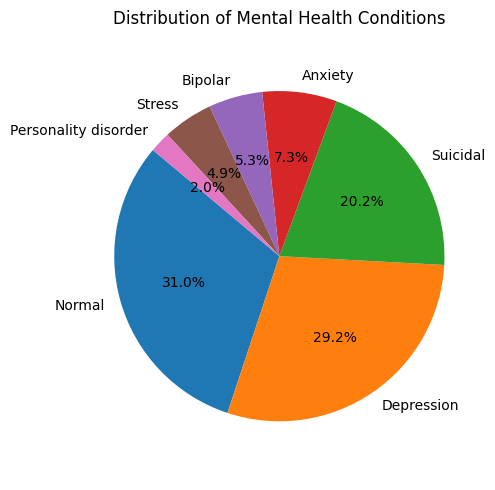

In [12]:
status_counts = posts['status'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', 
        startangle=140)

plt.title('Distribution of Mental Health Conditions')
plt.axis('equal') 
plt.tight_layout()
plt.show()

In [13]:
# Group by status and get a random statement from each group
random_statements = posts.groupby('status')['statement'].apply(lambda x: x.sample(n=1).iloc[0])

for status, statement in random_statements.items():
    print(f"Status: {status}")
    print(f"Statement: {statement}\n")

Status: Anxiety
Statement: Tired of being restless every day :'(

Status: Bipolar
Statement: I draw better when i'm hypomanic My eyes hurt, this is now my 5th piece in two days.. i guess i could be doing much worse things right now, at least im improving at something :D

Status: Depression
Statement: after year of constantly feeling dead inside i m starting to wondering if i ve actually died at some point and i just never realized it like in m night shyamalan s the sixth sense

Status: Normal
Statement: @nellypt Thank you I thought it was. Pass it around. Have a great day Luv ur stuff

Status: Personality disorder
Statement: suspecting avpd hi. i suspect i may have avpd, or something related to it. i’d like to preface this post by saying that i started reading up on this disorder about an hour ago, so clearly i’m not going to jump to any conclusions here, or at least i’m not trying to. i just think it’s possible. i also have adhd and i’m on a waitlist to be tested for autism. if that h

In [14]:
#Preprocessing

In [15]:
import re

In [16]:
posts.rename(columns={'statement': 'org_selftext'}, inplace=True)  

posts['selftext']=posts['org_selftext'].str.lower()
posts.sample(5)

,org_selftext,status,selftext
27005,Goodnight everyone I hope I do not wake up tom...,Suicidal,goodnight everyone i hope i do not wake up tom...
52977,Fear of future and spouses death Reacently the...,Anxiety,fear of future and spouses death reacently the...
24806,"I wish I died when I was a child, having exper...",Suicidal,"i wish i died when i was a child, having exper..."
51131,I’m a success story :) hey all.\n\nI have been...,Personality disorder,i’m a success story :) hey all.\n\ni have been...
13810,"I am (23, M) stuck at a dead-end job and, to t...",Depression,"i am (23, m) stuck at a dead-end job and, to t..."


In [17]:
def remove(text):
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

In [18]:
posts['selftext'] = posts['selftext'].apply(remove)

In [19]:
posts.sample(5)

,org_selftext,status,selftext
47488,I stopped taking my meds.. I was diagnosed 2 y...,Depression,i stopped taking my meds i was diagnosed 2 yea...
316,I really do this istikhara prayer. The excitem...,Anxiety,i really do this istikhara prayer the exciteme...
35148,Rabies Scare So I came upon a branch that had ...,Anxiety,rabies scare so i came upon a branch that had ...
43617,pfff i want to go back to bed i feel horrible ...,Normal,pfff i want to go back to bed i feel horrible ...
1564,telepathy???????,Normal,telepathy


In [20]:
import random
from wordcloud import WordCloud

import nltk
from scipy.sparse import hstack
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [21]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
posts['tokens'] = posts['selftext'].apply(word_tokenize)
posts.sample(5)

,org_selftext,status,selftext,tokens
23203,I am the kind of person that craves touch and ...,Depression,i am the kind of person that craves touch and ...,"[i, am, the, kind, of, person, that, craves, t..."
39555,for starter i ve suffered from ocd my entire l...,Depression,for starter i ve suffered from ocd my entire l...,"[for, starter, i, ve, suffered, from, ocd, my,..."
7903,So my fiance has came to a conclusion that I a...,Depression,so my fiance has came to a conclusion that i a...,"[so, my, fiance, has, came, to, a, conclusion,..."
20209,The only thing i keep myself alive for is self...,Depression,the only thing i keep myself alive for is self...,"[the, only, thing, i, keep, myself, alive, for..."
39082,it wasn t to bad it s pretty easy but i wa sti...,Depression,it wasn t to bad it s pretty easy but i wa sti...,"[it, wasn, t, to, bad, it, s, pretty, easy, bu..."


In [23]:
stemmer = PorterStemmer()
def stem_tokens(tokens):
    return ' '.join(stemmer.stem(str(token)) for token in tokens)

In [24]:
posts['tokens_stemmed'] = posts['tokens'].apply(stem_tokens)
posts.sample(5)

,org_selftext,status,selftext,tokens,tokens_stemmed
48508,Neighbor gave me a gift should I give back? It...,Stress,neighbor gave me a gift should i give back it ...,"[neighbor, gave, me, a, gift, should, i, give,...",neighbor gave me a gift should i give back it ...
2947,Damn I swear I can't read on the ipad afraid o...,Normal,damn i swear i cant read on the ipad afraid of...,"[damn, i, swear, i, cant, read, on, the, ipad,...",damn i swear i cant read on the ipad afraid of...
11498,"I just do not belong to this world, never did....",Suicidal,i just do not belong to this world never did t...,"[i, just, do, not, belong, to, this, world, ne...",i just do not belong to thi world never did th...
20069,I really hate having to wait about a week for ...,Suicidal,i really hate having to wait about a week for ...,"[i, really, hate, having, to, wait, about, a, ...",i realli hate have to wait about a week for th...
29179,"We've known each other for 9 years, were FWB ...",Normal,weve known each other for 9 years were fwb for...,"[weve, known, each, other, for, 9, years, were...",weve known each other for 9 year were fwb for ...


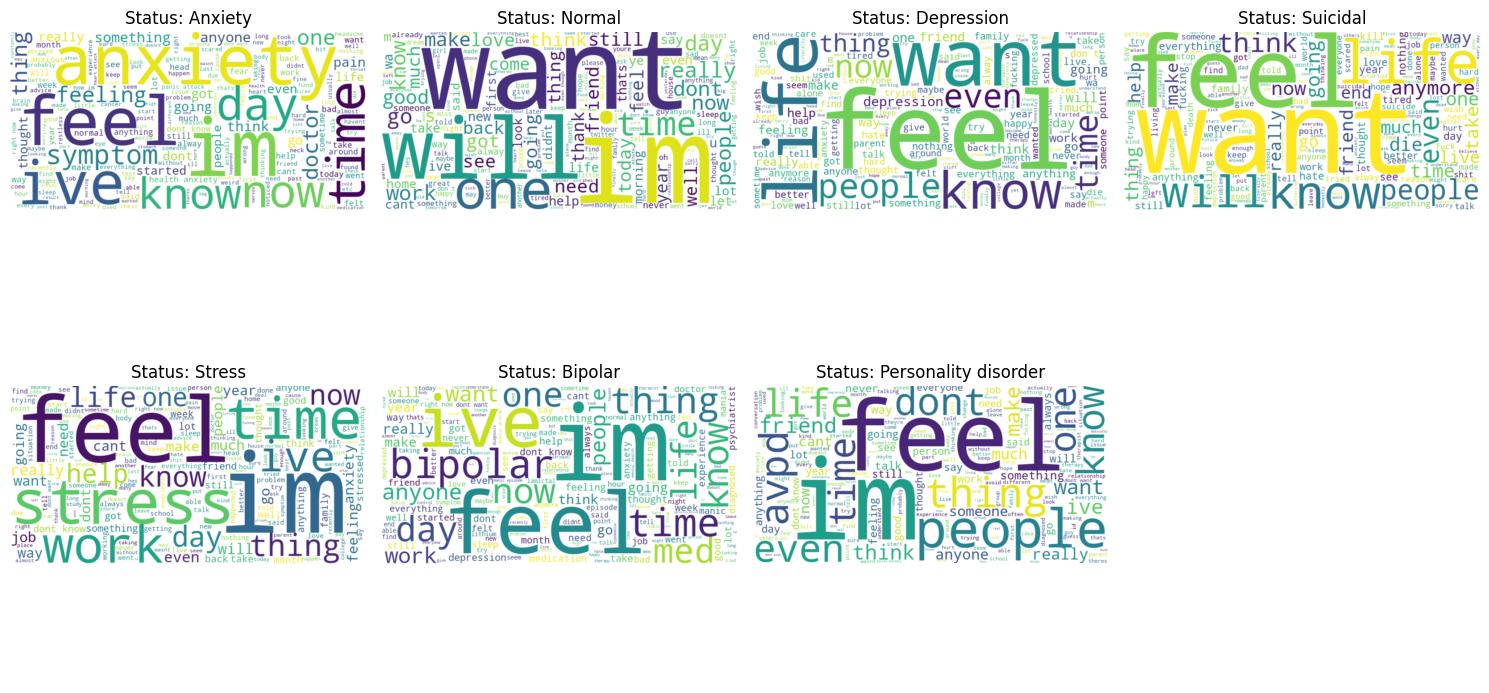

In [25]:
statuses = posts['status'].unique()

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for idx, status in enumerate(statuses[:7]):
    tokens_data = ' '.join(posts[posts['status'] == status]['tokens'].dropna().apply(lambda x: ' '.join(x)).tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(tokens_data)
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'Status: {status}')

for idx in range(len(statuses), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [26]:
# Calculate the number of characters and sentences
posts['chars'] = posts['selftext'].str.len()
posts['senten'] = posts['selftext'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [27]:
posts.sample(5)

,org_selftext,status,selftext,tokens,tokens_stemmed,chars,senten
25795,I am unlovable and talked down to. I am a bag ...,Depression,i am unlovable and talked down to i am a bag o...,"[i, am, unlovable, and, talked, down, to, i, a...",i am unlov and talk down to i am a bag of cell...,250,1
36438,"@TylersDunflower,Trench,I'm not feeling happy",Suicidal,trenchim not feeling happy,"[trenchim, not, feeling, happy]",trenchim not feel happi,26,1
29145,"She's talked about a restraining order, but I ...",Normal,shes talked about a restraining order but i do...,"[shes, talked, about, a, restraining, order, b...",she talk about a restrain order but i dont kno...,369,1
37254,with my financial situation getting worse so d...,Suicidal,with my financial situation getting worse so d...,"[with, my, financial, situation, getting, wors...",with my financi situat get wors so doe my ment...,260,1
21734,I have lots of people in mylife that love and ...,Depression,i have lots of people in mylife that love and ...,"[i, have, lots, of, people, in, mylife, that, ...",i have lot of peopl in mylif that love and car...,669,1


In [28]:
#Creating environment for BERT Fine-Tuning

In [29]:
from transformers import TFAutoModel, AutoTokenizer
import warnings
warnings.filterwarnings('ignore',category=DeprecationWarning)

In [30]:
model=TFAutoModel.from_pretrained('bert-base-uncased')

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

In [31]:
tokenizer=AutoTokenizer.from_pretrained('bert-base-uncased')

In [32]:
def tokenize(batch):
    return tokenizer(batch.tolist(), padding=True, truncation=True, return_tensors="pt")

In [33]:
mh=posts[['tokens_stemmed','status']]

In [34]:
mh

,tokens_stemmed,status
0,oh my gosh,Anxiety
1,troubl sleep confus mind restless heart all ou...,Anxiety
2,all wrong back off dear forward doubt stay in ...,Anxiety
3,ive shift my focu to someth els but im still w...,Anxiety
4,im restless and restless it been a month now b...,Anxiety
...,...,...
53038,nobodi take me serious ive 24m dealt with depr...,Anxiety
53039,selfish i dont feel veri good it like i dont b...,Anxiety
53040,is there ani way to sleep better i cant sleep ...,Anxiety
53041,public speak tip hi all i have to give a prese...,Anxiety


In [35]:
lbl_enc = LabelEncoder()
mh['status_encodes'] = lbl_enc.fit_transform(mh['status'].values)

In [36]:
mh.sample(5)

,tokens_stemmed,status,status_encodes
36728,âand iâm so sick of love song so tire of tear ...,Suicidal,6
37393,i thought iâv hate myself befor but now i real...,Suicidal,6
5356,dog,Normal,3
4424,ayi standri follow ayi,Normal,3
18274,i do not know what to do anymor i just want to...,Suicidal,6


In [37]:
mh_encoded=tokenize(mh['tokens_stemmed'])

In [38]:
mh_encoded

{'input_ids': tensor([[  101,  2821,  2026,  ...,     0,     0,     0],
        [  101, 19817,  7140,  ...,     0,     0,     0],
        [  101,  2035,  3308,  ...,     0,     0,     0],
        ...,
        [  101,  2003,  2045,  ...,     0,     0,     0],
        [  101,  2270,  3713,  ...,     0,     0,     0],
        [  101,  1045,  2031,  ...,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}

In [39]:
mh_encoded1 = []
for i in range(len(mh_encoded['input_ids'])):
    mh_encoded1.append([mh_encoded['input_ids'][i].tolist(), mh_encoded['token_type_ids'][i].tolist(), mh_encoded['attention_mask'][i].tolist()])

In [40]:
print(mh_encoded1[0][0])
print(mh_encoded1[1][0])

[101, 2821, 2026, 2175, 4095, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [41]:
mh_encoded2 = pd.DataFrame(mh_encoded1, columns=['input_ids', 'token_type_ids', 'attention_mask'])

In [42]:
mh_encoded2.sample(2)

,input_ids,token_type_ids,attention_mask
31714,"[101, 1045, 2123, 2102, 2066, 2256, 5210, 102,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ..."
5000,"[101, 2022, 29278, 1996, 2980, 7842, 14194, 19...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [43]:
mh_encoded2 = pd.concat([mh_encoded2, mh[['status', 'status_encodes']]], axis=1)

In [46]:
mh_encoded2.sample(5)

,input_ids,token_type_ids,attention_mask,status,status_encodes
25549,"[101, 1045, 2572, 2756, 16215, 2072, 2095, 202...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",Suicidal,6.0
49534,"[101, 3308, 22605, 2078, 2061, 1045, 3745, 199...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",NaN,NaN
33225,"[101, 2821, 2008, 2061, 3972, 28775, 102, 0, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",Normal,3.0
24092,"[101, 1045, 2064, 2025, 2393, 2021, 2022, 9006...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",Depression,2.0
20669,"[101, 2985, 1996, 2627, 2261, 2733, 2000, 3113...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",Suicidal,6.0


In [45]:
mh_encoded2.to_csv('tensors.csv', index=True)

In [47]:
file_path = 'tensors.csv'
data = pd.read_csv(file_path)

subset_data = data.sample(n=2485, random_state=42).reset_index(drop=True)

output_path = 'final.csv'
subset_data.to_csv(output_path, index=False)

print(f"Subset file saved to {output_path}")

Subset file saved to final.csv
